In [1]:
import baseline_electricity_model
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

In [2]:
from baseline_electricity_model import run_pipeline, run_pipeline_v2, summarize_model_stats, predict_demand, get_school_holidays

In [3]:
_, region_zone_map = get_school_holidays(list(range(2010, 2025)))

## Régions françaises

In [4]:
CONSO_PATH = "base_data/FR_elec/conso_reg_daily.csv"
TEMP_PATH = "base_data/temp_era/temp_FR_daily_era.csv"

temp = pd.read_csv(TEMP_PATH, index_col = 0, parse_dates = True)
conso = pd.read_csv(CONSO_PATH, index_col = 0, parse_dates = True)

In [5]:
models, baselines, calendar_df = run_pipeline_v2(CONSO_PATH, TEMP_PATH, training_period=list(range(2016, 2025, 1)), exclude_full_covid_y=False, alpha = 0.4, alpha_cdd=0.6, month_effect=False)

[load_data] Période retenue : 2016-01-01 → 2024-12-31
[load_data] Régions : ['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']
[load_data] N jours : 2831

[calendar] Génération des variables calendaires...
[calendar] 29 variables générées

=== ESTIMATION OLS V2 PAR RÉGION ===

  Calendrier       : v2 (sat+pont, vac décomposées, début-août)
  Température HDD  : T_eff(alpha=0.4)
  Température CDD  : T_eff(alpha=0.6)
  Années exclues   : {'Auvergne-Rhône-Alpes': 'A', 'Bourgogne-Franche-Comté': 'A', 'Nouvelle-Aquitaine': 'A', 'Centre-Val de Loire': 'B', 'Île-de-France': 'C', 'Normandie': 'B', 'Hauts-de-France': 'B', 'Bretagne': 'B', 'Pays de la Loire': 'B', 'Grand Est': 'B', 'Occitanie': 'C', "Provence-Alpes-Côte d'Azur": 'B', 'Corse': 'B'}

Région                                  R²  R²adj     RMSE   Tc1   Tc

In [6]:
models["Île-de-France"]

{'results': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1fa0c961b40>,
 'T_c1': 14.0,
 'T_c2': 19.0,
 'alpha_eff': 0.4,
 'calendar_v': 2}

Attention le prochain script dure 7 minutes

In [19]:
alphas = np.linspace(0.1,1,10)
best_R2 = 0
best_alpha = 0
validation_pred = {}
for a in alphas:
    # On fait tourner le modèle
    models, baselines, calendar_df = run_pipeline_v2(CONSO_PATH, TEMP_PATH, training_period=list(range(2016, 2025, 1)), exclude_full_covid_y=False, alpha = a)
    r2_adj = summarize_model_stats(models)[["R2", "R2_adj", "RMSE", "AIC", "BIC"]].mean()["R2_adj"]
    # On regarde quel alpha a le meilleur R2 moyen.
    if r2_adj > best_R2:
        best_alpha = a
        best_R2 = r2_adj
    
    # On prédit pour 2015 afin de pouvoir comparer ces prédictions
    y_pred = pd.DataFrame()
    for r in baselines.columns:
        y_pred[r] = predict_demand(models[r], r, region_zone_map, temp[r].loc["2015"])["y_pred"]
    validation_pred[a] = y_pred

print(f"Optimal alpha: {best_alpha} with a R2-score of {best_R2}")

[load_data] Période retenue : 2016-01-01 → 2024-12-31
[load_data] Régions : ['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']
[load_data] N jours : 2831

[calendar] Génération des variables calendaires...
[calendar] 29 variables générées

=== ESTIMATION OLS V2 PAR RÉGION ===

  Calendrier       : v2 (sat+pont, vac décomposées, début-août)
  Température HDD  : T_eff(alpha=0.1)
  Années exclues   : {'Auvergne-Rhône-Alpes': 'A', 'Bourgogne-Franche-Comté': 'A', 'Nouvelle-Aquitaine': 'A', 'Centre-Val de Loire': 'B', 'Île-de-France': 'C', 'Normandie': 'B', 'Hauts-de-France': 'B', 'Bretagne': 'B', 'Pays de la Loire': 'B', 'Grand Est': 'B', 'Occitanie': 'C', "Provence-Alpes-Côte d'Azur": 'B', 'Corse': 'B'}

Région                                  R²  R²adj     RMSE   Tc1   Tc2     N
------------------------------

Il faudrait valider sur certaines années, ex: 2015

In [20]:
def print_metrics(y_true, y_pred):
    rmse = root_mean_squared_error(y_pred=y_pred, y_true=y_true)
    mape = mean_absolute_percentage_error(y_pred=y_pred, y_true=y_true)
    mae = mean_absolute_error(y_pred=y_pred, y_true=y_true)
    print(f"Mean Absolute Error: {mae:.1f}")
    print(f"Mean Absolute Percentage Error: {mape*100:.2f}%")
    print(f"Root Mean Squared Error: {rmse:.1f}")
    return mae, mape, rmse

In [25]:
y_true = conso.loc["2015"] # on récup les vraies valeurs pour 2015
best_alpha = 0
best_rmse = 100000
for a in alphas:
    # On récup la prédiction faite dans la boucle ci-dessus
    y_pred = validation_pred[a]
    # On compare sur les valeurs de alpha
    print(f"Evaluation pour alpha = {a}:")
    mae, mape, rmse = print_metrics(y_true, y_pred)
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a
print("-----------------------------------------------")
print("-----------------------------------------------")
print(f"Based on validation on 2015 and best RMSE score, the best alpha is {best_alpha}")


Evaluation pour alpha = 0.1:
Mean Absolute Error: 184.6
Mean Absolute Percentage Error: 4.01%
Root Mean Squared Error: 259.8
Evaluation pour alpha = 0.2:
Mean Absolute Error: 153.2
Mean Absolute Percentage Error: 3.41%
Root Mean Squared Error: 202.7
Evaluation pour alpha = 0.30000000000000004:
Mean Absolute Error: 140.9
Mean Absolute Percentage Error: 3.19%
Root Mean Squared Error: 181.4
Evaluation pour alpha = 0.4:
Mean Absolute Error: 137.8
Mean Absolute Percentage Error: 3.15%
Root Mean Squared Error: 175.3
Evaluation pour alpha = 0.5:
Mean Absolute Error: 139.3
Mean Absolute Percentage Error: 3.20%
Root Mean Squared Error: 177.0
Evaluation pour alpha = 0.6:
Mean Absolute Error: 143.8
Mean Absolute Percentage Error: 3.30%
Root Mean Squared Error: 183.1
Evaluation pour alpha = 0.7000000000000001:
Mean Absolute Error: 149.6
Mean Absolute Percentage Error: 3.43%
Root Mean Squared Error: 191.3
Evaluation pour alpha = 0.8:
Mean Absolute Error: 156.1
Mean Absolute Percentage Error: 3.57%


La valeur optimale nous donne 0.4 pour alpha, donc avec une forte inertie en hiver

<Axes: title={'center': 'Île-de-France 2025 — décomposition'}, xlabel='Date'>

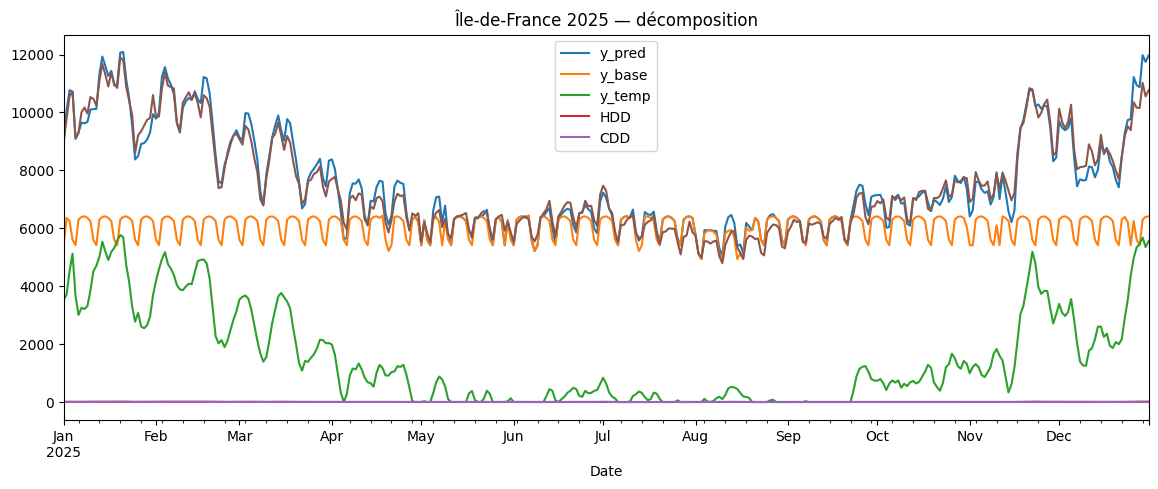

In [8]:
from baseline_electricity_model import predict_demand, plot_predictions_vs_actual, evaluate_predictions

# Reconstruire la demande pour l'Île-de-France sur 2022
df = predict_demand(
    models["Île-de-France"],
    "Île-de-France",
    region_zone_map,
    temp["Île-de-France"].loc["2025"]
)

# df contient :
# y_pred : demande totale (calendaire + T°)
# y_base : demande structurelle pure (sans effet T°)
# y_temp : part de la demande due à la température

df.plot(figsize=(14, 5), title="Île-de-France 2025 — décomposition")
conso["Île-de-France"].loc["2025"].plot(label = "y_true")


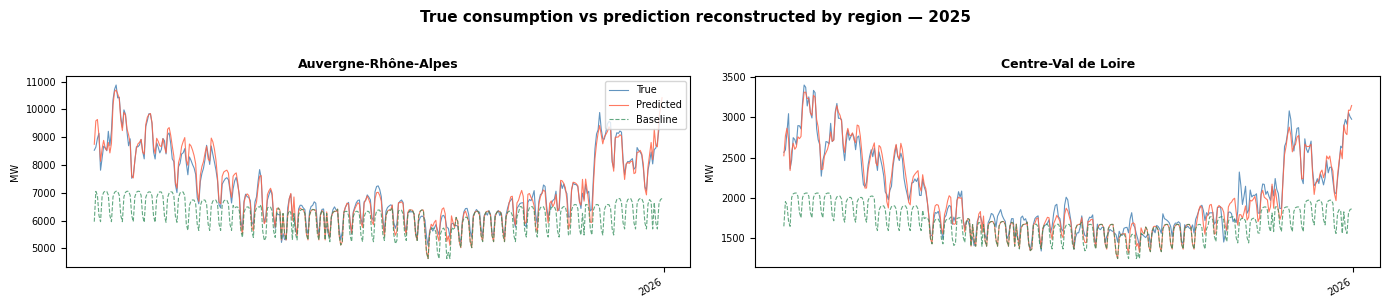

In [16]:
plot_predictions_vs_actual(models, conso, temp, region_zone_map, 2025, ncols = 2, regs= ["Auvergne-Rhône-Alpes", "Centre-Val de Loire"])

In [14]:
df_pred = {}
true_conso = 0
predict_conso = 0

for r in conso.columns:
    df_pred[r] = predict_demand(models[r], r, region_zone_map, temp[r].loc["2025"])
    true_conso += conso[r].loc["2025"]
    predict_conso += df_pred[r]["y_pred"]

In [15]:
for r in conso.columns:
    evaluate_predictions(conso[r].loc["2025"], df_pred[r]["y_pred"],
                   label=f"{r} 2025")

[eval] Auvergne-Rhône-Alpes 2025
  RMSE  :        226 MWh/j
  MAE   :        175 MWh/j
  MAPE  :       2.50 %
  N     :        365 jours
[eval] Bourgogne-Franche-Comté 2025
  RMSE  :        108 MWh/j
  MAE   :         80 MWh/j
  MAPE  :       3.70 %
  N     :        365 jours
[eval] Bretagne 2025
  RMSE  :         92 MWh/j
  MAE   :         70 MWh/j
  MAPE  :       2.82 %
  N     :        365 jours
[eval] Centre-Val de Loire 2025
  RMSE  :        107 MWh/j
  MAE   :         83 MWh/j
  MAPE  :       4.26 %
  N     :        365 jours
[eval] Grand Est 2025
  RMSE  :        193 MWh/j
  MAE   :        152 MWh/j
  MAPE  :       3.26 %
  N     :        365 jours
[eval] Hauts-de-France 2025
  RMSE  :        157 MWh/j
  MAE   :        124 MWh/j
  MAPE  :       2.37 %
  N     :        365 jours
[eval] Normandie 2025
  RMSE  :        122 MWh/j
  MAE   :         94 MWh/j
  MAPE  :       3.15 %
  N     :        365 jours
[eval] Nouvelle-Aquitaine 2025
  RMSE  :        212 MWh/j
  MAE   :        169

In [19]:
evaluate_predictions(true_conso, predict_conso,
                   label=f"France 2025")

[eval] France 2025
  RMSE  :      1,402 MWh/j
  MAE   :      1,052 MWh/j
  MAPE  :       2.12 %
  N     :        365 jours


RMSE       1401.70
MAE        1052.00
MAPE_%        2.12
N_jours     365.00
Name: France 2025, dtype: float64

#### Coefficients analysis

In [8]:
conso.columns

Index(['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne',
       'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie',
       'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire',
       'Provence-Alpes-Côte d'Azur', 'Île-de-France'],
      dtype='object')

In [9]:
def print_coefficients(models, region):
    m        = models[region]
    results  = m["results"]
    params   = results.params
    pvalues  = results.pvalues
    conf     = results.conf_int()

    print(f"\n{'='*65}")
    print(f"  {region}  |  T_c1 = {m['T_c1']:.2f}°C  |  T_c2 = {m['T_c2']:.2f}°C  |  R² = {results.rsquared:.4f}")
    print(f"{'='*65}")
    print(f"  {'Variable':<25} {'Coeff':>12} {'IC 95% bas':>12} {'IC 95% haut':>12}  {'p':>7}")
    print(f"  {'-'*63}")
    for var in params.index:
        sig = "***" if pvalues[var] < 0.001 else "**" if pvalues[var] < 0.01 else "*" if pvalues[var] < 0.05 else ""
        print(f"  {var:<25} {params[var]:>12.1f} {conf.loc[var,0]:>12.1f} {conf.loc[var,1]:>12.1f}  "
              f"{pvalues[var]:>6.4f} {sig}")

for reg in conso.columns :
    print_coefficients(models, reg)


  Auvergne-Rhône-Alpes  |  T_c1 = 12.50°C  |  T_c2 = 17.50°C  |  R² = 0.9578
  Variable                         Coeff   IC 95% bas  IC 95% haut        p
  ---------------------------------------------------------------
  const                           5654.0       5601.9       5706.2  0.0000 ***
  HDD                              288.4        280.9        296.0  0.0000 ***
  CDD                               87.6         74.6        100.7  0.0000 ***
  dow_0                            902.5        873.5        931.5  0.0000 ***
  dow_1                           1057.2       1024.1       1090.4  0.0000 ***
  dow_2                           1097.4       1063.0       1131.8  0.0000 ***
  dow_3                           1089.1       1054.6       1123.6  0.0000 ***
  dow_4                            951.8        918.9        984.7  0.0000 ***
  is_sat_or_bridge                 219.7        194.7        244.7  0.0000 ***
  is_eve                          -175.3       -245.7       -104.8  0

#### Computation of thermosensitive demand

We have 16 years of temperatures between 2010 and 2025

In [17]:
thermosensitive_demand = 0

for r in conso.columns:
    df = predict_demand(models[r], r, region_zone_map, temp[r])
    thermosensitive_demand += df["y_temp"].sum()/1000 * 24 # En GW puis passage en GWh car sur une journée

annual_thermosensitive_demand = thermosensitive_demand/16/1000

print(f"Annual demand for cooling and heating depending on temperature: {annual_thermosensitive_demand:.2f} TWh")

Annual demand for cooling and heating depending on temperature: 66.30 TWh


In [12]:
def calcul_demande_moyenne_thermosensible(models, reg, region_zone_map, temp, nb_years = 16):
    HDD_tot = predict_demand(models[reg], reg, region_zone_map, temp[reg], False)["HDD"].sum()
    CDD_tot = predict_demand(models[reg], reg, region_zone_map, temp[reg], False)["CDD"].sum()

    cool_rate = models[reg]["results"].params["CDD"]
    heat_rate = models[reg]["results"].params["HDD"]

    cool_demand = cool_rate*CDD_tot/1e6*24/nb_years 
    heat_demand = heat_rate*HDD_tot/1e6*24/nb_years

    #print(f"Demande thermosensible moyenne en {reg}:")
    #print(f"heating: {heat_demand:.2f} TWh/an, cooling: {cool_demand:.2f} TWh/an")

    return heat_demand, cool_demand

In [16]:
tot_heat = 0
tot_cool = 0
for r in temp.columns:
    #print(r)
    heat, cool = calcul_demande_moyenne_thermosensible(models, r, region_zone_map, temp)
    tot_heat += heat
    tot_cool += cool
print(f"Demande thermosensible moyenne en France:")
print(f"heating: {tot_heat:.2f} TWh/an, cooling: {tot_cool:.2f} TWh/an")

Demande thermosensible moyenne en France:
heating: 63.05 TWh/an, cooling: 2.81 TWh/an


In [17]:
cooling_rate = 0
heating_rate = 0
for r in models.keys():
    a = models[r]["results"].params
    cooling_rate += a["CDD"]
    heating_rate +=  a["HDD"]

print(f"National rates:       cooling -> {cooling_rate:.1f} MW/°C     ,       heating --> {heating_rate:.1f} MW/°C")

National rates:       cooling -> 636.4 MW/°C     ,       heating --> 2096.3 MW/°C


In [22]:
df_thresh_n_rates = pd.DataFrame(index = temp.columns)
df_thresh_n_rates["heating_rate"] = 0
df_thresh_n_rates["heating_threshold"] = 0
df_thresh_n_rates["cooling_rate"] = 0
df_thresh_n_rates["cooling_threshold"] = 0
for r in df_thresh_n_rates.index:
    df_thresh_n_rates["heating_rate"].loc[r] = models[r]["results"].params["HDD"]
    df_thresh_n_rates["cooling_rate"].loc[r] = models[r]["results"].params["CDD"]
    df_thresh_n_rates["heating_threshold"].loc[r] = models[r]["T_c1"]
    df_thresh_n_rates["cooling_threshold"].loc[r] = models[r]["T_c2"]

df_thresh_n_rates.to_csv("elec_thermo_parameters.csv")

#### Baselines

In [34]:
import matplotlib.pyplot as plt

In [35]:
r = "Île-de-France"
r2 = "Bretagne"
baseline = predict_demand(models[r], r, region_zone_map, temp[r].loc["2025"])["y_base"]
baseline2 = predict_demand(models[r2], r2, region_zone_map, temp[r2].loc["2025"])["y_base"]

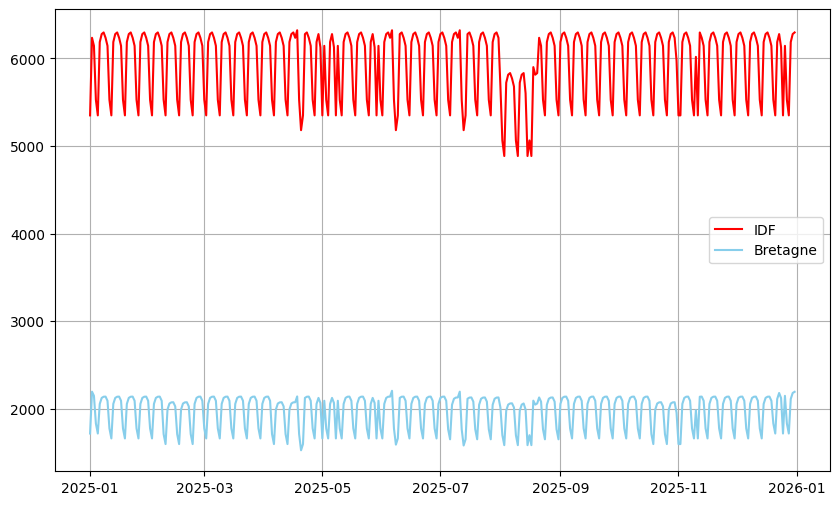

In [36]:
plt.figure(figsize = (10,6))
plt.plot(baseline, color = "red", label = "IDF")
plt.plot(baseline2, color = "skyblue", label = "Bretagne")
plt.legend()
plt.grid()
plt.show()

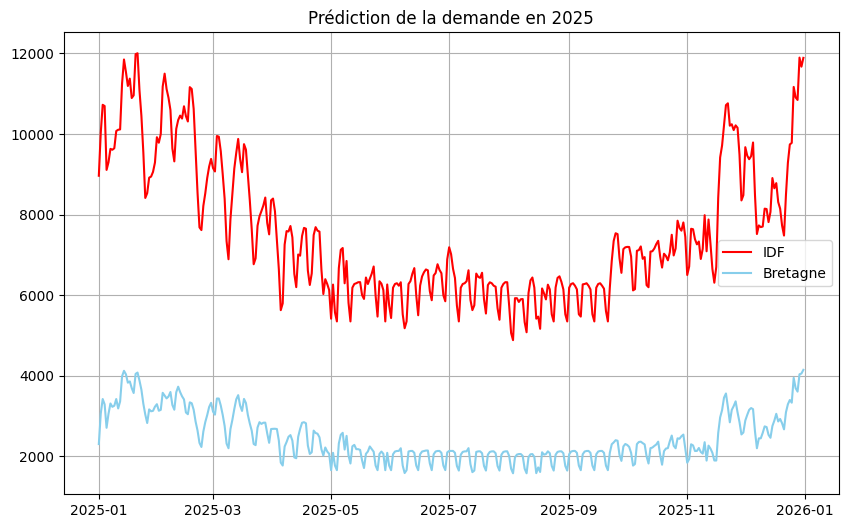

In [37]:
r = "Île-de-France"
r2 = "Bretagne"
baseline = predict_demand(models[r], r, region_zone_map, temp[r].loc["2025"])["y_pred"]
baseline2 = predict_demand(models[r2], r2, region_zone_map, temp[r2].loc["2025"])["y_pred"]

plt.figure(figsize = (10,6))
plt.plot(baseline, color = "red", label = "IDF")
plt.plot(baseline2, color = "skyblue", label = "Bretagne")
plt.legend()
plt.title("Prédiction de la demande en 2025")
plt.grid()
plt.show()

In [17]:
df = pd.DataFrame()
for r in conso.columns:
    df[r] = predict_demand(models[r], r, region_zone_map, temp[r])["y_base"]

In [20]:
df.to_csv("baseline_noT_elec_regions.csv")

In [26]:
print("Liste des années concernées:",list(temp.index.year.unique()))

Liste des années concernées: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


### Test sans month_effect :

In [6]:
models_nom, baselines_nom, calendar_df = run_pipeline_v2(CONSO_PATH, TEMP_PATH, training_period=list(range(2017, 2025, 1)), exclude_full_covid_y=False, alpha = 0.4, alpha_cdd=0.6, month_effect=False)

[load_data] Période retenue : 2017-01-01 → 2024-12-31
[load_data] Régions : ['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie', 'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Île-de-France']
[load_data] N jours : 2465

[calendar] Génération des variables calendaires...
[calendar] 29 variables générées

=== ESTIMATION OLS V2 PAR RÉGION ===

  Calendrier       : v2 (sat+pont, vac décomposées, début-août)
  Température HDD  : T_eff(alpha=0.4)
  Température CDD  : T_eff(alpha=0.6)
  Années exclues   : {'Auvergne-Rhône-Alpes': 'A', 'Bourgogne-Franche-Comté': 'A', 'Nouvelle-Aquitaine': 'A', 'Centre-Val de Loire': 'B', 'Île-de-France': 'C', 'Normandie': 'B', 'Hauts-de-France': 'B', 'Bretagne': 'B', 'Pays de la Loire': 'B', 'Grand Est': 'B', 'Occitanie': 'C', "Provence-Alpes-Côte d'Azur": 'B', 'Corse': 'B'}

Région                                  R²  R²adj     RMSE   Tc1   Tc

##### Extraction baseline et prédiction

In [8]:
from baseline_electricity_model import predict_demand, plot_predictions_vs_actual, evaluate_predictions

df = pd.DataFrame()
df_base = pd.DataFrame()

for r in conso.columns:

    df[r] = predict_demand(
        models_nom[r],
        r,
        region_zone_map,
        temp[r]
    )["y_pred"]

    df_base[r] = predict_demand(
        models_nom[r],
        r,
        region_zone_map,
        temp[r]
    )["y_base"]

# df.to_csv("final_predictions/alternative_predictions/no_temp_effect_18_25.csv")
df_base.to_csv("final_predictions/daily_baselines/baseline_no_month_elec.csv")

##### Extraction des pentes

In [10]:
df_thresh_n_rates = pd.DataFrame(index = temp.columns)
df_thresh_n_rates["heating_rate"] = 0
df_thresh_n_rates["heating_threshold"] = 0
df_thresh_n_rates["cooling_rate"] = 0
df_thresh_n_rates["cooling_threshold"] = 0
for r in df_thresh_n_rates.index:
    df_thresh_n_rates["heating_rate"].loc[r] = models_nom[r]["results"].params["HDD"]
    df_thresh_n_rates["cooling_rate"].loc[r] = models_nom[r]["results"].params["CDD"]
    df_thresh_n_rates["heating_threshold"].loc[r] = models_nom[r]["T_c1"]
    df_thresh_n_rates["cooling_threshold"].loc[r] = models_nom[r]["T_c2"]

df_thresh_n_rates.to_csv("final_predictions/thresholds_and_rates/elec_thermo_parameters_no_month.csv")

In [28]:
true_2025 = conso.loc["2014"].sum(axis=1)
pred_2025 = df.sum(axis = 1)

In [27]:
evaluate_predictions(true_2025, pred_2025, "No month effect")

[eval] No month effect
  RMSE  :      1,699 MWh/j
  MAE   :      1,300 MWh/j
  MAPE  :       2.57 %
  N     :        365 jours


RMSE       1699.20
MAE        1300.10
MAPE_%        2.57
N_jours     365.00
Name: No month effect, dtype: float64

<Axes: title={'center': 'Île-de-France 2024 — décomposition'}, xlabel='Date'>

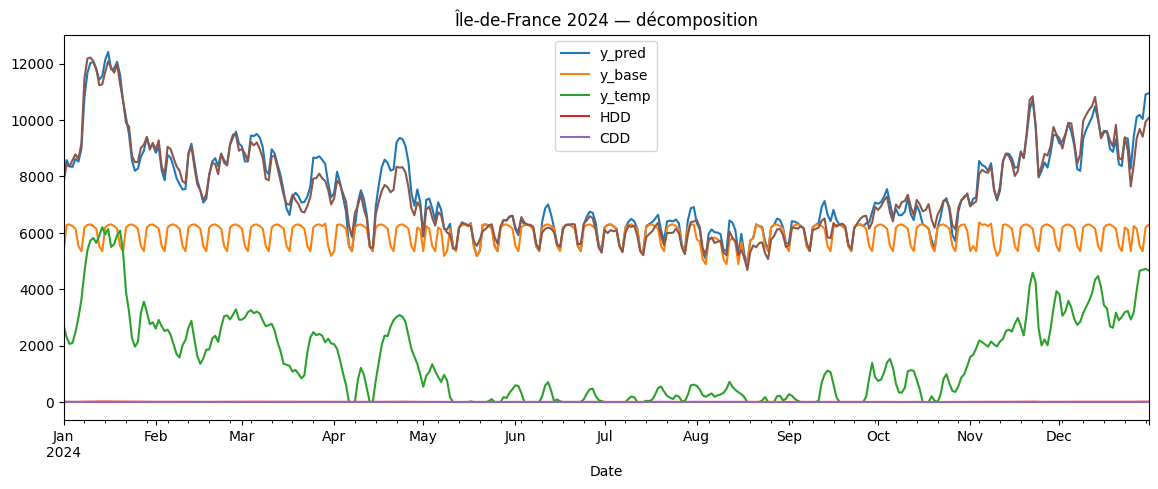

: 

In [ ]:

# Reconstruire la demande pour l'Île-de-France sur 2022
df = predict_demand(
    models_nom["Île-de-France"],
    "Île-de-France",
    region_zone_map,
    temp["Île-de-France"].loc["2024"]
)

# df contient :
# y_pred : demande totale (calendaire + T°)
# y_base : demande structurelle pure (sans effet T°)
# y_temp : part de la demande due à la température

df.plot(figsize=(14, 5), title="Île-de-France 2024 — décomposition")
conso["Île-de-France"].loc["2024"].plot(label = "y_true")

In [13]:
tot_heat = 0
tot_cool = 0
for r in temp.columns:
    #print(r)
    heat, cool = calcul_demande_moyenne_thermosensible(models_nom, r, region_zone_map, temp)
    tot_heat += heat
    tot_cool += cool
print(f"Demande thermosensible moyenne en France:")
print(f"heating: {tot_heat:.2f} TWh/an, cooling: {tot_cool:.2f} TWh/an")

Demande thermosensible moyenne en France:
heating: 81.42 TWh/an, cooling: 2.47 TWh/an


In [14]:
cooling_rate = 0
heating_rate = 0
for r in models.keys():
    a = models[r]["results"].params
    cooling_rate += a["CDD"]
    heating_rate +=  a["HDD"]

print(f"National rates:       cooling -> {cooling_rate:.1f} MW/°C     ,       heating --> {heating_rate:.1f} MW/°C")

National rates:       cooling -> 652.8 MW/°C     ,       heating --> 2454.7 MW/°C


Baselines

In [42]:
base = pd.DataFrame()
base_nom = pd.DataFrame()
for r in conso.columns:
    base[r] = predict_demand(
        models[r],
        r,
        region_zone_map,
        temp[r]
    )["y_base"]
    base_nom[r] = predict_demand(
        models_nom[r],
        r,
        region_zone_map,
        temp[r]
    )["y_base"]

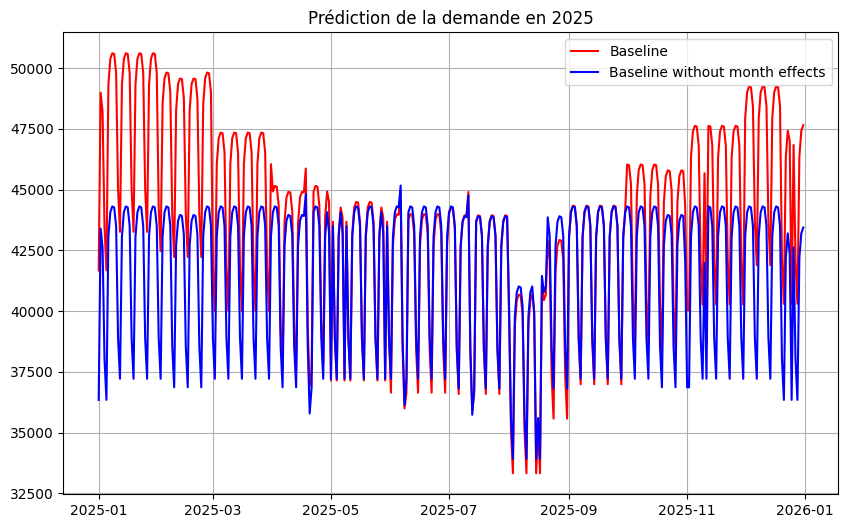

In [44]:
plt.figure(figsize = (10,6))
plt.plot(base.sum(axis=1).loc["2025"], color = "red", label = "Baseline")
plt.plot(base_nom.sum(axis=1).loc["2025"], color = "blue", label = "Baseline without month effects")
plt.legend()
plt.title("Prédiction de la demande en 2025")
plt.grid()
plt.show()